In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Set plot style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')


## 1. Data Preparation and EDA
We will use the classic **Iris Dataset**. It contains 150 samples of iris flowers, with 4 features (sepal length, sepal width, petal length, petal width) and 3 target classes (Setosa, Versicolor, Virginica).


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


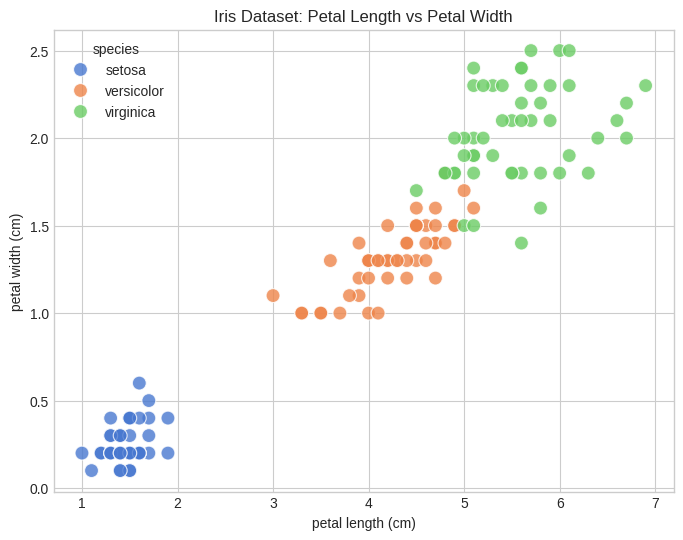

Training samples: 105, Testing samples: 45


In [11]:
# Load the Iris dataset

iris = load_iris()

X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Create a DataFrame for visualization
df = pd.DataFrame(X, columns=feature_names)
df['species'] = [target_names[i] for i in y]

# Display the first few rows
display(df.head())

# Visualizing feature relationships
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='petal length (cm)', y='petal width (cm)', hue='species', s=100, alpha=0.8)
plt.title('Iris Dataset: Petal Length vs Petal Width')
plt.show()

# Split data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")


## 2. Decision Tree: Manual Root Node Finding
A Decision Tree splits data recursively. But how does it find the *very first* split (the root node)?
Algorithms like CART evaluate every feature and every possible threshold value to find the split that minimizes **Gini Impurity**.

**Gini Impurity Formula:**
$Gini = 1 - \sum (P_i)^2$
Where $P_i$ is the probability of a class in that node.

Let's write a function to calculate Gini, and then iterate through our features manually to find the best split!


In [12]:
def calculate_gini(labels):
    '''Calculate Gini impurity for a given set of labels'''
    # If node is empty, impurity is 0
    if len(labels) == 0:
        return 0.0

    # Count occurrences of each class
    _, counts = np.unique(labels, return_counts=True)

    # Calculate probabilities
    probabilities = counts / len(labels)

    # Calculate Gini
    gini = 1.0 - np.sum(probabilities**2)
    return gini

def evaluate_split(X, y, feature_index, threshold):
    '''Calculate the weighted Gini impurity of a specific split'''
    left_mask = X[:, feature_index] <= threshold
    right_mask = ~left_mask

    y_left = y[left_mask]
    y_right = y[right_mask]

    # Weighted average of Gini impurities
    n = len(y)
    gini_left = calculate_gini(y_left)
    gini_right = calculate_gini(y_right)

    weighted_gini = (len(y_left) / n) * gini_left + (len(y_right) / n) * gini_right
    return weighted_gini

# --- MANUAL SEARCH FOR THE ROOT NODE ---
best_gini = float('inf')
best_feature = -1
best_threshold = -1

print("--- Manual Root Node Search ---")
# Iterate over all 4 features
for feature_idx in range(X_train.shape[1]):
    # Sort the unique values of the feature to use as thresholds
    thresholds = np.unique(X_train[:, feature_idx])

    # Iterate over all unique values as potential split points
    for threshold in thresholds:
        gini = evaluate_split(X_train, y_train, feature_idx, threshold)

        if gini < best_gini:
            best_gini = gini
            best_feature = feature_idx
            best_threshold = threshold

print(f"Best Feature to Split: '{feature_names[best_feature]}' (Index {best_feature})")
print(f"Best Threshold Value: <= {best_threshold}")
print(f"Minimum Weighted Gini Impurity achieved: {best_gini:.4f}")


--- Manual Root Node Search ---
Best Feature to Split: 'petal length (cm)' (Index 2)
Best Threshold Value: <= 1.9
Minimum Weighted Gini Impurity achieved: 0.3524


### 2.1 Verifying with Scikit-Learn
Now, let's train a `scikit-learn` Decision Tree on the same data and plot it. We should see the **exact same root node** chosen by the algorithm.


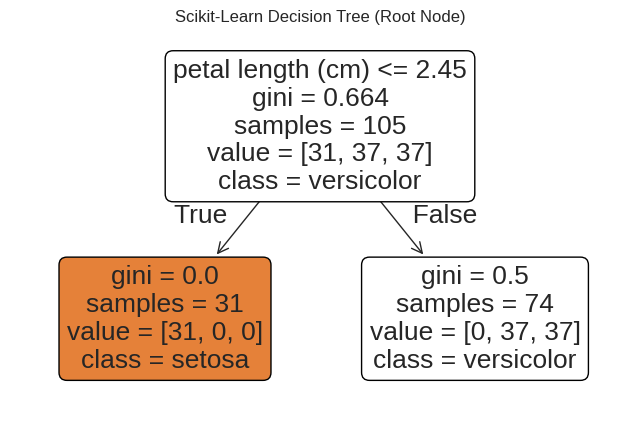

--- Scikit-Learn Verification ---
Scikit-Learn chose feature: 'petal length (cm)'
Scikit-Learn chose threshold: <= 2.4500
✅ SUCCESS: Manual feature selection matches Scikit-Learn!


In [13]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Initialize and train Scikit-learn Decision Tree
dt_clf = DecisionTreeClassifier(max_depth=1, random_state=42) # Depth 1 just to see root
dt_clf.fit(X_train, y_train)

# Visualize the tree
plt.figure(figsize=(8, 5))
plot_tree(dt_clf, feature_names=feature_names, class_names=target_names, filled=True, rounded=True)
plt.title("Scikit-Learn Decision Tree (Root Node)")
plt.show()

# Verification check
tree_feature_idx = dt_clf.tree_.feature[0]
tree_threshold = dt_clf.tree_.threshold[0]

print("--- Scikit-Learn Verification ---")
print(f"Scikit-Learn chose feature: '{feature_names[tree_feature_idx]}'")
print(f"Scikit-Learn chose threshold: <= {tree_threshold:.4f}")

if tree_feature_idx == best_feature:
    print("✅ SUCCESS: Manual feature selection matches Scikit-Learn!")
else:
    print("❌ MISMATCH in feature selection.")


## 3. k-Nearest Neighbors (kNN): Manual Prediction
kNN doesn't "learn" an equation. When given a new data point, it:
1. Calculates the distance between the new point and *all* training points.
2. Sorts the distances to find the $k$ closest neighbors.
3. Takes a majority vote among those neighbors to predict the class.

Let's manually implement the Euclidean distance and classification logic for a single test point.


In [14]:
def euclidean_distance(point1, point2):
    distance = np.sqrt(np.sum((point1 - point2)**2))
    return distance

def manual_knn_predict(X_train, y_train, test_point, k=5):
    '''Manually predict the class of a single test point'''
    # 1. Calculate distances from test_point to all points in X_train
    distances = [euclidean_distance(test_point, x) for x in X_train]

    # 2. Get indices of the k smallest distances
    # np.argsort returns the indices that would sort an array
    k_indices = np.argsort(distances)[:k]

    # 3. Get the labels of the k nearest neighbors
    k_nearest_labels = [y_train[i] for i in k_indices]

    # 4. Majority vote
    # np.unique returns unique elements and their counts
    unique_labels, counts = np.unique(k_nearest_labels, return_counts=True)
    predicted_label = unique_labels[np.argmax(counts)]

    return predicted_label, k_nearest_labels, distances

# Let's test it on the VERY FIRST sample in our test set
test_sample = X_test[0]
true_label = y_test[0]
k_value = 5

manual_pred, neighbors, _ = manual_knn_predict(X_train, y_train, test_sample, k=k_value)

print(f"--- Manual kNN Prediction (k={k_value}) ---")
print(f"Test Point Features: {test_sample}")
print(f"True Class: {target_names[true_label]}")
print(f"Neighbor Votes: {[target_names[n] for n in neighbors]}")
print(f"Manual Prediction: {target_names[manual_pred]}")


--- Manual kNN Prediction (k=5) ---
Test Point Features: [6.1 2.8 4.7 1.2]
True Class: versicolor
Neighbor Votes: [np.str_('versicolor'), np.str_('versicolor'), np.str_('versicolor'), np.str_('versicolor'), np.str_('versicolor')]
Manual Prediction: versicolor


### 3.1 Verifying with Scikit-Learn
Let's use `KNeighborsClassifier` to predict the same test point and ensure it matches our manual logic.
We'll also plot the decision boundaries created by kNN to build intuition on how it creates non-linear classification regions.


--- Scikit-Learn kNN Verification ---
Scikit-Learn Prediction: versicolor
✅ SUCCESS: Manual kNN prediction matches Scikit-Learn!


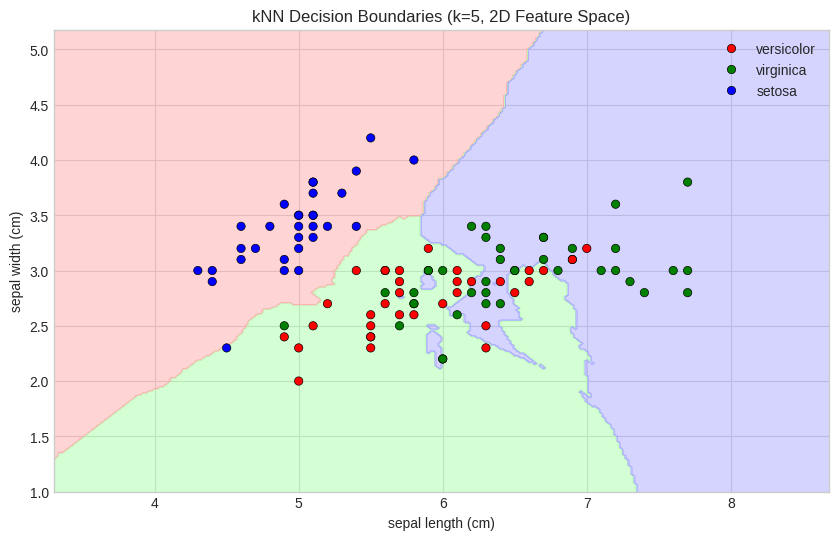

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap

# Train Scikit-Learn kNN
knn_clf = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_clf.fit(X_train, y_train)

# Predict the first test point
sklearn_pred = knn_clf.predict([test_sample])[0]

print("--- Scikit-Learn kNN Verification ---")
print(f"Scikit-Learn Prediction: {target_names[sklearn_pred]}")
if sklearn_pred == manual_pred:
    print("✅ SUCCESS: Manual kNN prediction matches Scikit-Learn!")
else:
    print("❌ MISMATCH in kNN prediction.")

# --- INTUITION VISUALIZATION: Decision Boundaries ---
# To visualize in 2D, we will only use the first two features (Sepal Length and Sepal Width)
X_vis = X_train[:, :2]
knn_vis = KNeighborsClassifier(n_neighbors=5)
knn_vis.fit(X_vis, y_train)

# Create a mesh grid
h = .02  # step size in the mesh
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict for every point in the mesh
Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotting
plt.figure(figsize=(10, 6))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.5)
sns.scatterplot(x=X_vis[:, 0], y=X_vis[:, 1], hue=[target_names[y] for y in y_train],
                palette=['red', 'green', 'blue'], edgecolor="black")

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title("kNN Decision Boundaries (k=5, 2D Feature Space)")
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.show()


## 4. Evaluation Metrics
Finally, let's look at how to evaluate these classifiers. We'll manually calculate **Accuracy**, which is the simplest metric, and then use Scikit-Learn's `classification_report` to compute Precision, Recall, and F-Measure.


--- Manual Accuracy Calculation ---
Decision Tree (Depth=1) Accuracy: 0.7111
kNN (k=5) Accuracy: 1.0000
--- Scikit-Learn Classification Report (kNN) ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



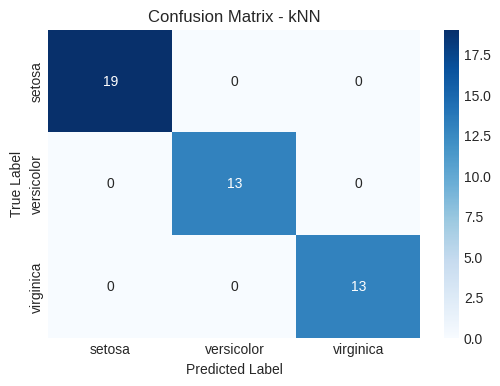

In [16]:
from sklearn.metrics import classification_report, confusion_matrix

# Get full test set predictions
dt_full_preds = dt_clf.predict(X_test)
knn_full_preds = knn_clf.predict(X_test)

# Manual Accuracy calculation
def calculate_accuracy(y_true, y_pred):
    correct = np.sum(y_true == y_pred)
    total = len(y_true)
    return correct / total

print("--- Manual Accuracy Calculation ---")
print(f"Decision Tree (Depth=1) Accuracy: {calculate_accuracy(y_test, dt_full_preds):.4f}")
print(f"kNN (k=5) Accuracy: {calculate_accuracy(y_test, knn_full_preds):.4f}")

# Scikit-Learn Classification Report
print("--- Scikit-Learn Classification Report (kNN) ---")
print(classification_report(y_test, knn_full_preds, target_names=target_names))

# Confusion Matrix Heatmap for kNN
cm = confusion_matrix(y_test, knn_full_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - kNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


## 5. Cross-Validation for Robust Evaluation

While a single train-test split gives us an idea of performance, it can be sensitive to the particular split. **Cross-validation** provides a more robust estimate of a model's performance by splitting the data into multiple folds and training/testing the model on different combinations of these folds.

We will use **K-Fold Cross-Validation**, where the dataset is divided into K equal-sized folds. The model is trained K times; each time, one fold is used as the test set and the remaining K-1 folds are used as the training set. The final performance metric is the average of the K results.

In [17]:
from sklearn.model_selection import KFold, cross_val_score

# --- Decision Tree Cross-Validation ---
print("--- Decision Tree (Depth=1) Cross-Validation ---")

dt_clf_cv = DecisionTreeClassifier(max_depth=1, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42) # 5-Fold Cross-Validation

dt_scores = cross_val_score(dt_clf_cv, X, y, cv=kf, scoring='accuracy')

print(f"Individual fold accuracies: {dt_scores}")
print(f"Mean Accuracy: {dt_scores.mean():.4f}")
print(f"Standard Deviation: {dt_scores.std():.4f}")

--- Decision Tree (Depth=1) Cross-Validation ---
Individual fold accuracies: [0.63333333 0.66666667 0.66666667 0.6        0.6       ]
Mean Accuracy: 0.6333
Standard Deviation: 0.0298


In [18]:
# --- kNN Cross-Validation ---
print("\n--- kNN (k=5) Cross-Validation ---")

knn_clf_cv = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
kf = KFold(n_splits=5, shuffle=True, random_state=42) # 5-Fold Cross-Validation

knn_scores = cross_val_score(knn_clf_cv, X, y, cv=kf, scoring='accuracy')

print(f"Individual fold accuracies: {knn_scores}")
print(f"Mean Accuracy: {knn_scores.mean():.4f}")
print(f"Standard Deviation: {knn_scores.std():.4f}")


--- kNN (k=5) Cross-Validation ---
Individual fold accuracies: [1.         1.         0.96666667 0.93333333 0.96666667]
Mean Accuracy: 0.9733
Standard Deviation: 0.0249


## 6. Exploring Overfitting and Underfitting with kNN

In this section, we will change the number of neighbors ($k$) and observe how it affects our model's performance on both the training data and unseen validation data.

**Key Concepts:**
*   **Overfitting ($k$ is too small):** The model memorizes the training data (e.g., $k=1$ usually gives 100% training accuracy) but fails to generalize, leading to a lower cross-validation accuracy.
*   **Underfitting ($k$ is too large):** The model becomes too simple and looks at too many points, blurring the boundaries. Both training and cross-validation accuracies drop.

Let's loop through $k$ values from 1 to 20 and plot the results:

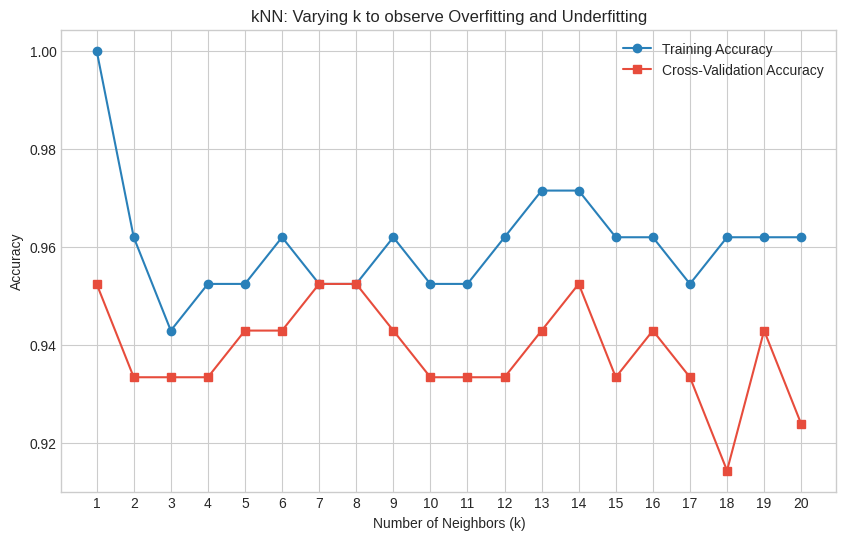

In [19]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

k_values = range(1, 21)
cv_scores = []
train_scores = []

# Loop over different values of k
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    # Calculate Training Accuracy
    knn.fit(X_train, y_train)
    train_scores.append(knn.score(X_train, y_train))

    # Calculate Cross-Validation Accuracy (using 5 folds)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, label='Training Accuracy', marker='o', color='#2980b9')
plt.plot(k_values, cv_scores, label='Cross-Validation Accuracy', marker='s', color='#e74c3c')
plt.title('kNN: Varying k to observe Overfitting and Underfitting')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()